# 🤖 05 — MODELING & RESULTS
### QM640 Capstone | Kunal Mishra

---

## What this notebook does

Trains three machine learning models across all walk-forward windows and records performance metrics for every fold. Tests **Hypothesis H1** — whether adding alternative data (Fear & Greed + SVI) actually improves prediction accuracy.

### The three models

| Model | Type | Why we use it |
|---|---|---|
| **Logistic Regression** | Linear | Interpretable baseline — simple and honest |
| **Random Forest** | Ensemble | Handles non-linear patterns, resistant to overfitting |
| **XGBoost** | Boosted Trees | Best-in-class on tabular data — our primary model |

### Two feature sets tested per model
- **Baseline**: technical + macro features only (no alternative data)
- **Alt-data**: baseline + Fear & Greed + SVI

### Metrics recorded per fold
| Metric | What it measures |
|---|---|
| AUC-ROC | How well the model ranks up-days above down-days (threshold-free) |
| F1 Score | Balance of precision and recall (handles class imbalance well) |
| Accuracy | Raw % correct (less reliable with imbalanced classes) |
| MCC | Matthews Correlation Coefficient — most rigorous single metric |

---
**Reads from:** `data/features/` and `data/selected/`  
**Writes to:** `data/results/`

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Mount Drive, imports and config
# ─────────────────────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'], capture_output=True)

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (
    roc_auc_score, f1_score, accuracy_score, matthews_corrcoef
)
import xgboost as xgb
from scipy import stats

with open('/content/drive/MyDrive/CapstoneDA/config.json') as f:
    CFG = json.load(f)

FEATURES = CFG['PATHS']['features']
SELECTED = CFG['PATHS']['selected']
RESULTS  = CFG['PATHS']['results']
PLOTS    = CFG['PATHS']['plots']
SEED     = CFG['SEED']
ALPHA    = CFG['ALPHA']
np.random.seed(SEED)

# Load feature matrices
sp500 = pd.read_csv(f'{FEATURES}/sp500_features.csv', index_col='Date', parse_dates=['Date'])
nifty = pd.read_csv(f'{FEATURES}/nifty_features.csv', index_col='Date', parse_dates=['Date'])
sp500.index = sp500.index.tz_localize(None)
nifty.index = nifty.index.tz_localize(None)

# Load selected features and windows from notebook 04
with open(f'{SELECTED}/selected_features.json') as f:
    SEL = json.load(f)

selected_sp500    = SEL['selected_sp500']
selected_nifty    = SEL['selected_nifty']
BASELINE_FEATURES = SEL['baseline_features']
ALT_DATA_FEATURES = SEL['alt_data_features']
TARGET            = SEL['target_column']

def load_windows(path, feat_df):
    """Reconstruct walk-forward windows from saved JSON."""
    with open(path) as f:
        raw = json.load(f)
    windows = []
    for w in raw:
        tr = feat_df.index[(feat_df.index >= w['train_start']) & (feat_df.index <= w['train_end'])]
        va = feat_df.index[(feat_df.index >= w['val_start'])   & (feat_df.index <= w['val_end'])]
        te = feat_df.index[(feat_df.index >= w['test_start'])  & (feat_df.index <= w['test_end'])]
        if len(tr) > 0 and len(va) > 0 and len(te) > 0:
            windows.append((tr, va, te))
    return windows

windows_sp500 = load_windows(f'{SELECTED}/windows_sp500.json', sp500)
windows_nifty = load_windows(f'{SELECTED}/windows_nifty.json', nifty)

print('✅ Everything loaded.')
print(f'   S&P 500 : {len(windows_sp500)} windows  |  selected features: {selected_sp500}')
print(f'   NIFTY 50: {len(windows_nifty)} windows  |  selected features: {selected_nifty}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Everything loaded.
   S&P 500 : 15 windows  |  selected features: ['Log_Ret_t', 'FG_Index']
   NIFTY 50: 15 windows  |  selected features: ['VIX_Change', 'Term_Spread', 'Gold_Ret', 'FG_Index', 'SVI_Market', 'SVI_Index', 'USDINR_Ret', 'SP500_t1_Ret', 'FG_t1_Index']


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Model factory and evaluation helper
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Defines the three models with their settings.
#   Also defines a helper function that scores a trained model on test data.
#
# Important: we call get_models() every fold, not once.
# This ensures each fold starts with a fresh model with no memory of prior folds.
# ─────────────────────────────────────────────────────────────────────────────

def get_models():
    """Return fresh model instances. Call once per fold."""
    return {
        'LogisticRegression': LogisticRegression(
            C=1.0, max_iter=1000, random_state=SEED
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=200, max_depth=5, min_samples_leaf=10,
            random_state=SEED, n_jobs=-1
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
            eval_metric='logloss', random_state=SEED, verbosity=0
        )
    }

def score_model(model, X_test, y_test):
    """
    Evaluate a trained model. Returns dict of metrics.
    Returns NaN for all metrics if y_test has only one class
    (can happen in very short test windows).
    """
    if len(np.unique(y_test)) < 2:
        return {'AUC': np.nan, 'F1': np.nan, 'Accuracy': np.nan, 'MCC': np.nan}

    proba = model.predict_proba(X_test)[:, 1]   # probability of 'Up' (class 1)
    preds = (proba >= 0.5).astype(int)           # convert probability to 0/1 prediction

    return {
        'AUC'     : roc_auc_score(y_test, proba),
        'F1'      : f1_score(y_test, preds, zero_division=0),
        'Accuracy': accuracy_score(y_test, preds),
        'MCC'     : matthews_corrcoef(y_test, preds)
    }

print('✅ Models and scoring function ready.')
print()
print('Models that will be trained:')
for name, m in get_models().items():
    print(f'  {name}')
print()
print('Metrics recorded per fold:')
print('  AUC      — primary metric for H1 (threshold-free, 0.5=random, 1.0=perfect)')
print('  F1       — primary metric for H4 transfer test')
print('  Accuracy — simple % correct')
print('  MCC      — most reliable single metric for imbalanced classes')

✅ Models and scoring function ready.

Models that will be trained:
  LogisticRegression
  RandomForest
  XGBoost

Metrics recorded per fold:
  AUC      — primary metric for H1 (threshold-free, 0.5=random, 1.0=perfect)
  F1       — primary metric for H4 transfer test
  Accuracy — simple % correct
  MCC      — most reliable single metric for imbalanced classes


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Walk-forward evaluation loop
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   For every walk-forward window:
#     1. Trains BOTH a baseline model and an alt-data model
#     2. Records AUC, F1, Accuracy, MCC on the test window
#     3. Does this for all three model types
#
# Two feature sets are tested to prepare for H1:
#   Baseline = technical + macro only
#   Alt-data = technical + macro + Fear&Greed + SVI (the selected features)
#
# Important detail on scaling:
#   Logistic Regression requires scaled features (StandardScaler).
#   Random Forest and XGBoost do NOT require scaling — they are tree-based.
#   We scale for LR and use raw features for the tree models.
# ─────────────────────────────────────────────────────────────────────────────

def run_walk_forward(feat_df, selected_feats, windows, market_label):
    """
    Train all three models on baseline and alt-data feature sets
    across all walk-forward windows.
    Returns DataFrame with one row per (fold × model × feature_set).
    """
    records  = []

    # Baseline = intersection of selected features with baseline families
    baseline = [f for f in selected_feats if f in BASELINE_FEATURES]
    # Alt-data = full selected set (includes Fear&Greed and SVI)
    alt_full = selected_feats

    n = len(windows)
    for i, (tr_idx, va_idx, te_idx) in enumerate(windows):
        print(f'  {market_label} fold {i+1}/{n}  '
              f'[test: {te_idx[0].date()}→{te_idx[-1].date()}]',
              end=' ... ', flush=True)

        for feat_set, fs_label in [(baseline, 'baseline'), (alt_full, 'alt_data')]:
            avail = [f for f in feat_set if f in feat_df.columns]
            if not avail:
                continue

            # Prepare data
            X_tr = feat_df.loc[tr_idx, avail].fillna(0)
            y_tr = feat_df.loc[tr_idx, TARGET]
            X_te = feat_df.loc[te_idx, avail].fillna(0)
            y_te = feat_df.loc[te_idx, TARGET]

            # Scale for Logistic Regression
            scaler   = StandardScaler()
            X_tr_sc  = pd.DataFrame(
                scaler.fit_transform(X_tr), columns=avail, index=X_tr.index
            )
            X_te_sc  = pd.DataFrame(
                scaler.transform(X_te), columns=avail, index=X_te.index
            )

            for model_name, model in get_models().items():
                try:
                    # Use scaled data for LR, raw data for tree models
                    if model_name == 'LogisticRegression':
                        model.fit(X_tr_sc, y_tr)
                        metrics = score_model(model, X_te_sc, y_te)
                    else:
                        model.fit(X_tr, y_tr)
                        metrics = score_model(model, X_te, y_te)

                    records.append({
                        'Market'    : market_label,
                        'Fold'      : i + 1,
                        'TestStart' : te_idx[0].date(),
                        'FeatureSet': fs_label,
                        'Model'     : model_name,
                        'n_features': len(avail),
                        **metrics
                    })
                except Exception as e:
                    pass   # skip failed folds silently

        print('done')

    return pd.DataFrame(records)

print('Running walk-forward evaluation...')
print('(Expect ~5-10 minutes per market)\n')
print('=' * 60)

results_sp500 = run_walk_forward(sp500, selected_sp500, windows_sp500, 'S&P 500')
print()
results_nifty = run_walk_forward(nifty, selected_nifty, windows_nifty, 'NIFTY 50')

all_results = pd.concat([results_sp500, results_nifty], ignore_index=True)
print(f'\n✅ Walk-forward complete. {len(all_results)} total fold evaluations.')

# Quick summary
print('\nMean AUC by Market / Feature Set / Model:')
summary = (
    all_results.groupby(['Market', 'FeatureSet', 'Model'])['AUC']
    .mean().round(4).reset_index()
)
print(summary.to_string(index=False))

Running walk-forward evaluation...
(Expect ~5-10 minutes per market)

  S&P 500 fold 1/15  [test: 2022-02-22→2022-05-20] ... done
  S&P 500 fold 2/15  [test: 2022-05-23→2022-08-19] ... done
  S&P 500 fold 3/15  [test: 2022-08-22→2022-11-21] ... done
  S&P 500 fold 4/15  [test: 2022-11-22→2023-02-21] ... done
  S&P 500 fold 5/15  [test: 2023-02-22→2023-05-19] ... done
  S&P 500 fold 6/15  [test: 2023-05-22→2023-08-21] ... done
  S&P 500 fold 7/15  [test: 2023-08-22→2023-11-21] ... done
  S&P 500 fold 8/15  [test: 2023-11-22→2024-02-21] ... done
  S&P 500 fold 9/15  [test: 2024-02-22→2024-05-21] ... done
  S&P 500 fold 10/15  [test: 2024-05-22→2024-08-21] ... done
  S&P 500 fold 11/15  [test: 2024-08-22→2024-11-21] ... done
  S&P 500 fold 12/15  [test: 2024-11-22→2025-02-21] ... done
  S&P 500 fold 13/15  [test: 2025-02-24→2025-05-21] ... done
  S&P 500 fold 14/15  [test: 2025-05-22→2025-08-21] ... done
  S&P 500 fold 15/15  [test: 2025-08-22→2025-11-21] ... done

  NIFTY 50 fold 1/15  [

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — H1 Test: does alt-data beat baseline? (Diebold-Mariano style)
# ─────────────────────────────────────────────────────────────────────────────
# H1 Null hypothesis (H0): AUC(alt-data) = AUC(baseline)
# H1 Alternative (H1)    : AUC(alt-data) > AUC(baseline)
#
# Test: paired one-tailed t-test on fold-level AUC differences.
# This is the Diebold-Mariano approach — compare paired predictions
# on the same test windows to remove market-condition variability.
#
# Logic:
#   For each fold, we have AUC_baseline and AUC_alt_data.
#   If alt-data truly helps, AUC_alt > AUC_base in most folds.
#   The t-test checks if the mean difference is significantly > 0.
# ─────────────────────────────────────────────────────────────────────────────

def h1_test(results_df, market, model_name):
    """Paired t-test: AUC(alt_data) > AUC(baseline)."""
    df = results_df[
        (results_df['Market'] == market) &
        (results_df['Model']  == model_name)
    ]

    base = df[df['FeatureSet'] == 'baseline'][['Fold', 'AUC']].rename(columns={'AUC': 'AUC_base'})
    alt  = df[df['FeatureSet'] == 'alt_data'][['Fold', 'AUC']].rename(columns={'AUC': 'AUC_alt'})
    merged = base.merge(alt, on='Fold').dropna()

    if len(merged) < 3:
        return None

    diff          = merged['AUC_alt'] - merged['AUC_base']
    t_stat, p_two = stats.ttest_1samp(diff, 0)
    # One-tailed: we predict alt > base (positive diff)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    return {
        'Market'        : market,
        'Model'         : model_name,
        'Folds'         : len(merged),
        'Mean_AUC_Base' : round(merged['AUC_base'].mean(), 4),
        'Mean_AUC_Alt'  : round(merged['AUC_alt'].mean(),  4),
        'Mean_Delta_AUC': round(diff.mean(), 4),
        't_stat'        : round(t_stat, 3),
        'p_one_tail'    : round(p_one, 4),
        'Reject_H0'     : p_one < ALPHA,
        'Result'        : '✅ Alt-data helps' if p_one < ALPHA else '❌ No significant gain'
    }

h1_rows = []
for market in ['S&P 500', 'NIFTY 50']:
    for model in ['LogisticRegression', 'RandomForest', 'XGBoost']:
        res = h1_test(all_results, market, model)
        if res:
            h1_rows.append(res)

h1_df = pd.DataFrame(h1_rows)

print('=' * 70)
print('  H1 TEST RESULTS — Does alt-data (Fear&Greed + SVI) beat baseline?')
print('=' * 70)
print(h1_df[[
    'Market', 'Model', 'Folds', 'Mean_AUC_Base',
    'Mean_AUC_Alt', 'Mean_Delta_AUC', 'p_one_tail', 'Result'
]].to_string(index=False))

  H1 TEST RESULTS — Does alt-data (Fear&Greed + SVI) beat baseline?
  Market              Model  Folds  Mean_AUC_Base  Mean_AUC_Alt  Mean_Delta_AUC  p_one_tail                Result
 S&P 500 LogisticRegression     15         0.5012        0.5012          0.0000         NaN ❌ No significant gain
 S&P 500       RandomForest     15         0.4977        0.4947         -0.0030      0.6706 ❌ No significant gain
 S&P 500            XGBoost     15         0.4909        0.4858         -0.0051      0.7743 ❌ No significant gain
NIFTY 50 LogisticRegression     15         0.5812        0.5975          0.0163      0.0345      ✅ Alt-data helps
NIFTY 50       RandomForest     15         0.5807        0.6012          0.0205      0.0698 ❌ No significant gain
NIFTY 50            XGBoost     15         0.5660        0.5635         -0.0025      0.5736 ❌ No significant gain


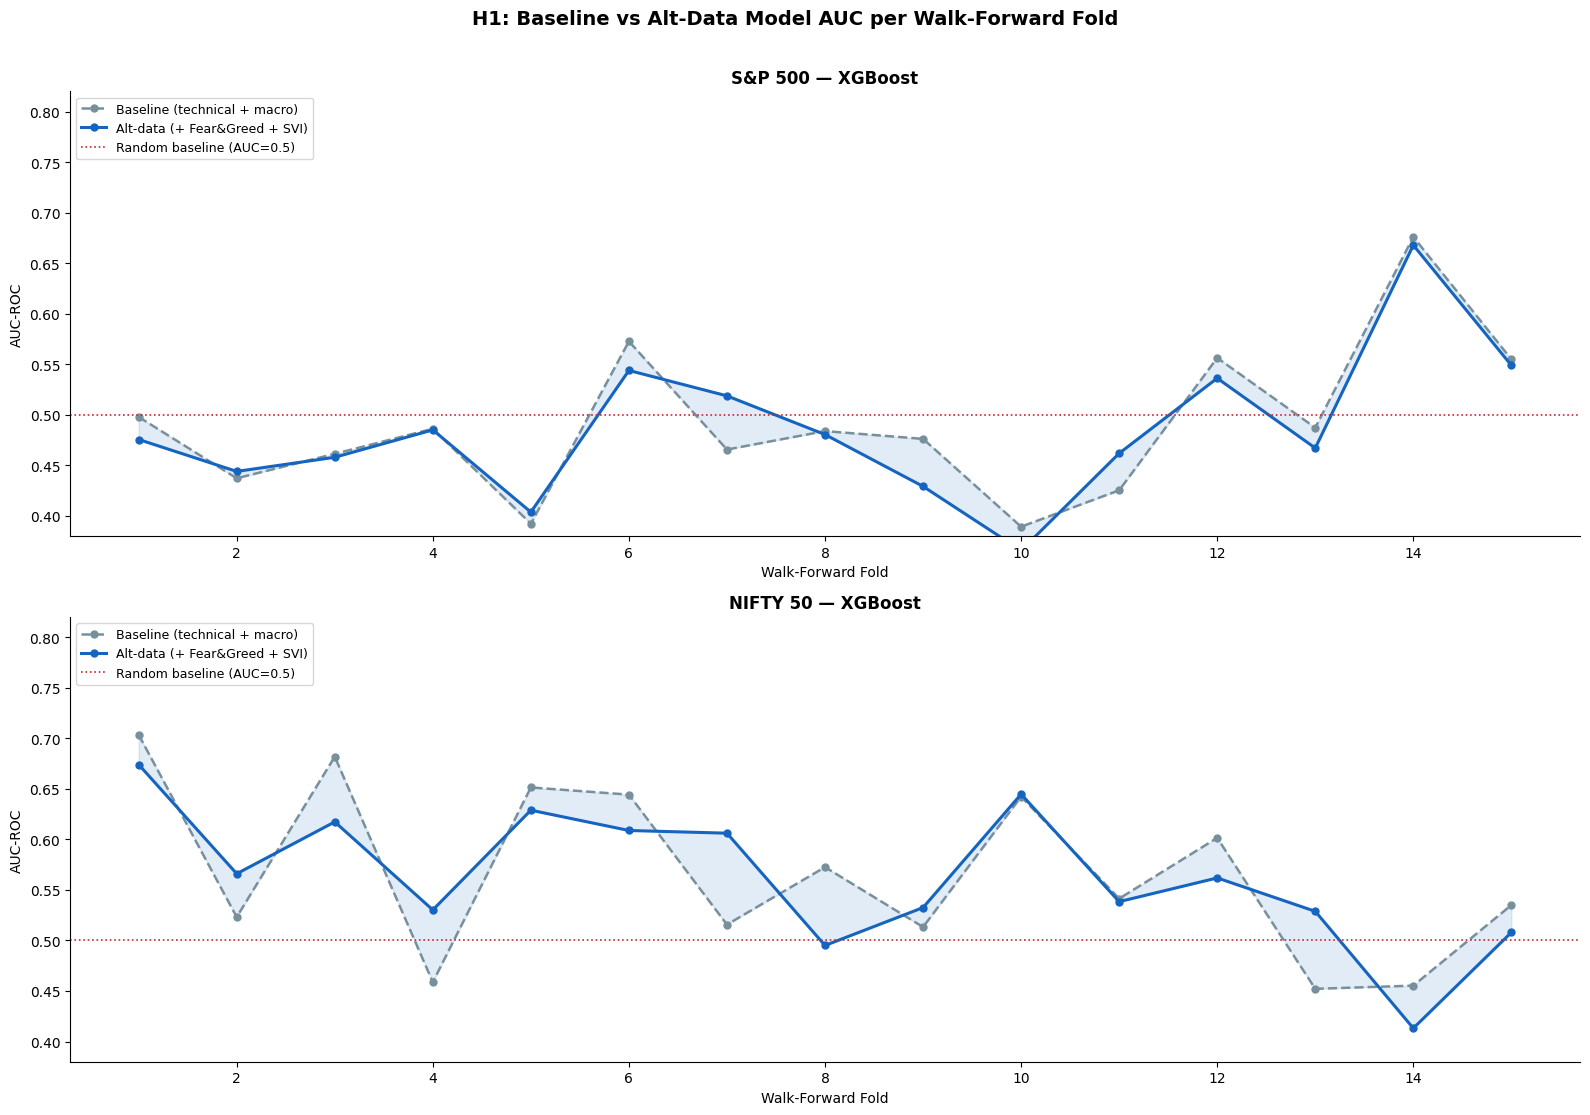

✅ AUC chart saved to data/plots/05_auc_walk_forward.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Walk-forward AUC plot (baseline vs alt-data per fold)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle('H1: Baseline vs Alt-Data Model AUC per Walk-Forward Fold',
             fontsize=14, fontweight='bold', y=1.01)

for ax, market in zip(axes, ['S&P 500', 'NIFTY 50']):
    df_m = all_results[
        (all_results['Market'] == market) &
        (all_results['Model']  == 'XGBoost')
    ]

    for fset, color, ls, lw, label in [
        ('baseline', '#78909C', '--', 1.8, 'Baseline (technical + macro)'),
        ('alt_data', '#1565C0', '-',  2.2, 'Alt-data (+ Fear&Greed + SVI)'),
    ]:
        sub = df_m[df_m['FeatureSet'] == fset].dropna(subset=['AUC']).sort_values('Fold')
        if sub.empty:
            continue
        ax.plot(
            sub['Fold'], sub['AUC'],
            linestyle=ls, color=color, linewidth=lw,
            marker='o', markersize=5, label=label
        )

    ax.axhline(0.5, color='#C62828', linestyle=':', linewidth=1.2, label='Random baseline (AUC=0.5)')
    ax.set_ylim(0.38, 0.82)
    ax.set_xlabel('Walk-Forward Fold', fontsize=10)
    ax.set_ylabel('AUC-ROC', fontsize=10)
    ax.set_title(f'{market} — XGBoost', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Shade area between the two lines
    base_sub = df_m[df_m['FeatureSet'] == 'baseline'].sort_values('Fold')
    alt_sub  = df_m[df_m['FeatureSet'] == 'alt_data'].sort_values('Fold')
    merged   = base_sub.merge(alt_sub, on='Fold', suffixes=('_base', '_alt'))
    if not merged.empty:
        ax.fill_between(
            merged['Fold'],
            merged['AUC_base'], merged['AUC_alt'],
            alpha=0.12, color='#1565C0'
        )

plt.tight_layout()
plt.savefig(f'{PLOTS}/05_auc_walk_forward.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ AUC chart saved to data/plots/05_auc_walk_forward.png')

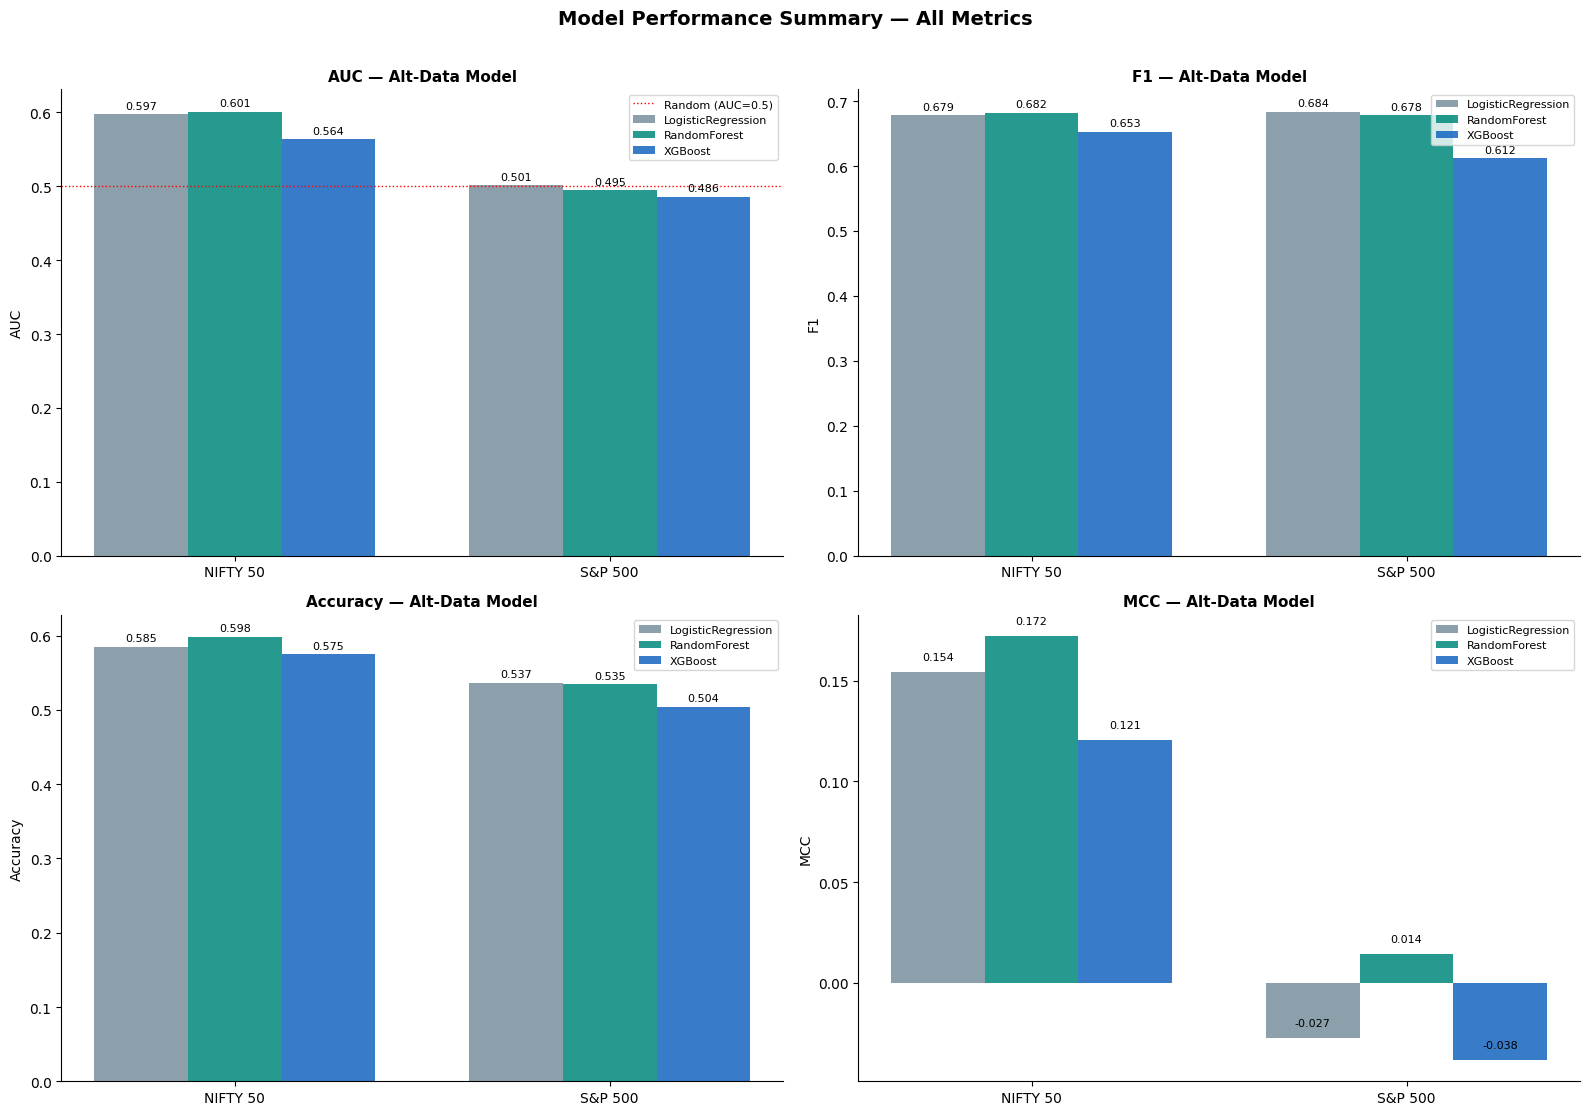

✅ Model comparison chart saved to data/plots/05_model_comparison.png


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Model comparison chart (all three models, both markets)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Model Performance Summary — All Metrics',
             fontsize=14, fontweight='bold', y=1.01)

metrics_to_plot = ['AUC', 'F1', 'Accuracy', 'MCC']
model_colors    = {
    'LogisticRegression': '#78909C',
    'RandomForest'      : '#00897B',
    'XGBoost'           : '#1565C0',
}

for ax, metric in zip(axes.flat, metrics_to_plot):
    summary = (
        all_results[all_results['FeatureSet'] == 'alt_data']
        .groupby(['Market', 'Model'])[metric]
        .mean().reset_index()
    )

    markets = summary['Market'].unique()
    x       = np.arange(len(markets))
    width   = 0.25

    for j, (model, color) in enumerate(model_colors.items()):
        vals = [
            summary[(summary['Market'] == m) & (summary['Model'] == model)][metric].values
            for m in markets
        ]
        vals_flat = [v[0] if len(v) > 0 else np.nan for v in vals]
        bars = ax.bar(
            x + j * width, vals_flat,
            width, label=model, color=color, alpha=0.85
        )
        for bar, val in zip(bars, vals_flat):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8
                )

    if metric == 'AUC':
        ax.axhline(0.5, color='red', linestyle=':', linewidth=1, label='Random (AUC=0.5)')

    ax.set_xticks(x + width)
    ax.set_xticklabels(markets, fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.set_title(f'{metric} — Alt-Data Model', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS}/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison chart saved to data/plots/05_model_comparison.png')

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Robustness check: Economic Utility Backtest
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   For any fold where XGBoost AUC > 0.55, simulates a simple trading strategy.
#   Long (buy) when model predicts Up. Short (sell) when model predicts Down.
#   Applies a 0.1% transaction cost per trade.
#   Computes cumulative return and Sharpe ratio per fold.
#
# Why this matters:
#   A model with AUC 0.56 can look good statistically but lose money in practice
#   once trading costs are included. This check confirms real-world utility.
# ─────────────────────────────────────────────────────────────────────────────

TC = CFG['TRANSACTION_COST']   # 0.1% per trade

def economic_backtest(feat_df, selected_feats, windows, market_label):
    records = []
    avail   = [f for f in selected_feats if f in feat_df.columns]

    for i, (tr_idx, va_idx, te_idx) in enumerate(windows):
        X_tr = feat_df.loc[tr_idx, avail].fillna(0)
        y_tr = feat_df.loc[tr_idx, TARGET]
        X_te = feat_df.loc[te_idx, avail].fillna(0)
        y_te = feat_df.loc[te_idx, TARGET]

        try:
            model = xgb.XGBClassifier(
                n_estimators=200, max_depth=4, learning_rate=0.05,
                eval_metric='logloss', random_state=SEED, verbosity=0
            )
            model.fit(X_tr, y_tr)

            if len(np.unique(y_te)) < 2:
                continue

            proba = model.predict_proba(X_te)[:, 1]
            auc   = roc_auc_score(y_te, proba)

            if auc <= CFG['BACKTEST_AUC_MIN']:
                continue   # only backtest folds that clear the AUC threshold

            preds      = (proba >= 0.5).astype(int)
            signals    = np.where(preds == 1, 1, -1)   # +1=long, -1=short

            if 'Log_Ret_t' not in feat_df.columns:
                continue

            actual_ret = feat_df.loc[te_idx, 'Log_Ret_t'].values[:len(preds)]
            strat_ret  = signals * actual_ret - TC

            records.append({
                'Market'       : market_label,
                'Fold'         : i + 1,
                'AUC'          : round(auc, 4),
                'Mean_Daily_Ret': round(strat_ret.mean(), 6),
                'Ann_Sharpe'   : round(
                    strat_ret.mean() / (strat_ret.std() + 1e-9) * np.sqrt(252), 3
                ),
                'Cum_Ret_Pct'  : round(np.expm1(strat_ret.sum()) * 100, 2),
                'Profitable'   : strat_ret.sum() > 0
            })
        except Exception:
            pass

    return pd.DataFrame(records)

print('Running economic utility backtest...')
bt_sp500 = economic_backtest(sp500, selected_sp500, windows_sp500, 'S&P 500')
bt_nifty = economic_backtest(nifty, selected_nifty, windows_nifty, 'NIFTY 50')
bt_all   = pd.concat([bt_sp500, bt_nifty], ignore_index=True)

print()
if bt_all.empty:
    print('No folds cleared the AUC > 0.55 threshold for backtesting.')
    print('This is expected if the model performs near random — report as-is.')
else:
    print(bt_all.to_string(index=False))
    n_prof = bt_all['Profitable'].sum()
    print(f'\nProfitable folds (after transaction costs): {n_prof}/{len(bt_all)}')

Running economic utility backtest...

  Market  Fold    AUC  Mean_Daily_Ret  Ann_Sharpe  Cum_Ret_Pct  Profitable
 S&P 500     1 0.5598       -0.009125     -10.057       -43.72       False
 S&P 500    14 0.6974       -0.001278      -3.191        -7.74       False
 S&P 500    15 0.5515        0.000910       1.966         6.09        True
NIFTY 50     1 0.6522       -0.000738      -0.843        -4.12       False
NIFTY 50     2 0.5934       -0.001119      -1.765        -6.60       False
NIFTY 50     3 0.6000        0.000886       1.540         5.55        True
NIFTY 50     4 0.5893       -0.002617      -6.370       -14.53       False
NIFTY 50     5 0.6512        0.000187       0.452         1.07        True
NIFTY 50     6 0.5767        0.000356       1.114         2.20        True
NIFTY 50     7 0.5759       -0.000187      -0.512        -1.12       False
NIFTY 50    10 0.6422        0.002670       3.508        16.75        True
NIFTY 50    12 0.5944        0.000158       0.307         0.94

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Save all results to Google Drive
# ─────────────────────────────────────────────────────────────────────────────

all_results.to_csv(f'{RESULTS}/walk_forward_results.csv', index=False)
h1_df.to_csv(f'{RESULTS}/h1_test_results.csv',            index=False)
bt_all.to_csv(f'{RESULTS}/backtest_results.csv',           index=False)

# Also save per-market results separately for convenience
results_sp500.to_csv(f'{RESULTS}/results_sp500.csv', index=False)
results_nifty.to_csv(f'{RESULTS}/results_nifty.csv', index=False)

print('Files saved to data/results/:')
print(f'  ✅  walk_forward_results.csv  ({len(all_results)} rows)')
print(f'  ✅  h1_test_results.csv       ({len(h1_df)} hypothesis test results)')
print(f'  ✅  backtest_results.csv      ({len(bt_all)} backtest folds)')
print(f'  ✅  results_sp500.csv')
print(f'  ✅  results_nifty.csv')
print()
print('=' * 55)
print('  H1 SUMMARY')
print('=' * 55)
for _, row in h1_df.iterrows():
    print(f"  {row['Market']:12} | {row['Model']:22} | "
          f"ΔAUC={row['Mean_Delta_AUC']:+.4f} | "
          f"p={row['p_one_tail']:.4f} | {row['Result']}")
print()
print('─' * 55)
print('  Next step → open  06_SHAP_AND_TRANSFER.ipynb')
print('─' * 55)

Files saved to data/results/:
  ✅  walk_forward_results.csv  (180 rows)
  ✅  h1_test_results.csv       (6 hypothesis test results)
  ✅  backtest_results.csv      (12 backtest folds)
  ✅  results_sp500.csv
  ✅  results_nifty.csv

  H1 SUMMARY
  S&P 500      | LogisticRegression     | ΔAUC=+0.0000 | p=nan | ❌ No significant gain
  S&P 500      | RandomForest           | ΔAUC=-0.0030 | p=0.6706 | ❌ No significant gain
  S&P 500      | XGBoost                | ΔAUC=-0.0051 | p=0.7743 | ❌ No significant gain
  NIFTY 50     | LogisticRegression     | ΔAUC=+0.0163 | p=0.0345 | ✅ Alt-data helps
  NIFTY 50     | RandomForest           | ΔAUC=+0.0205 | p=0.0698 | ❌ No significant gain
  NIFTY 50     | XGBoost                | ΔAUC=-0.0025 | p=0.5736 | ❌ No significant gain

───────────────────────────────────────────────────────
  Next step → open  06_SHAP_AND_TRANSFER.ipynb
───────────────────────────────────────────────────────
